In [31]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)


In [32]:
# Configure ORB detector
orb = cv.ORB_create(
    nfeatures=10000,
    scaleFactor=1.2,
    nlevels=16,
    scoreType=cv.ORB_HARRIS_SCORE
)

In [33]:
class FeatureExtraction:
    def __init__(self, img):
        self.img_orig = img
        self.img_8bit = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
        self.gray_img = cv.cvtColor(self.img_8bit, cv.COLOR_BGR2GRAY) if img.ndim == 3 else self.img_8bit
        
        if self.gray_img.dtype != np.uint8:
            self.gray_img = cv.normalize(self.gray_img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
        
        self.kps, self.des = orb.detectAndCompute(self.gray_img, None)
        self.matched_pts = []

In [34]:
class FeatureMatching():
    def __init__(self):
        
        self.LOWES_RATIO = 0.7
        self.MIN_MATCHES = 5
        self.index_params = dict(
            algorithm = 6, # FLANN_INDEX_LSH
            table_number = 6,
            key_size = 10,
            multi_probe_level = 2)
        self.search_params = dict(checks=50)
        self.flann = cv.FlannBasedMatcher( #(Fast Library for Approximate Nearest Neighbors)
            self.index_params,
            self.search_params)

    def feature_matching(self,features0: FeatureExtraction, features1:FeatureExtraction):
        matches = [] # good matches as per Lowe's ratio test
        
        #Checks if the first image has valid descriptors and at least 3 feature points (minimum needed for meaningful matching).
        if(features0.des is not None and len(features0.des) > 2):
            all_matches = self.flann.knnMatch( \
                features0.des, features1.des, k=2)
            try:
                for m,n in all_matches:
                    if m.distance < self.LOWES_RATIO * n.distance:
                        matches.append(m)
            except Exception as e:
                logger.error(f"Matching failed: {e}") 
                
            if(len(matches) > self.MIN_MATCHES):    
                features0.matched_pts = np.float32( \
                    [ features0.kps[m.queryIdx].pt for m in matches ] \
                        ).reshape(-1,1,2)
                
                features1.matched_pts = np.float32( \
                    [ features1.kps[m.trainIdx].pt for m in matches ] \
                        ).reshape(-1,1,2)
            else:
                logger.warning(f"Not enough matches found: {len(matches)}. not populating image features with matches Minimum required: {self.MIN_MATCHES}")   
                             
        return matches 

In [35]:
def featureMatching(ref_img, test_img):
    
    # Extract features
    if ref_img is not None and test_img is not None:
        ref_features = FeatureExtraction(ref_img)
        test_features = FeatureExtraction(test_img)
    
    # Match features
    matcher = FeatureMatching()
    matches = matcher.feature_matching(ref_features, test_features)
    
    # Display results
    print(f"Reference Keypoints: {len(ref_features.kps)}")
    print(f"Test Image Keypoints: {len(test_features.kps)}")
    print(f"Good Matches Found: {len(matches)}")
    print(f"Minimum Needed: {matcher.MIN_MATCHES} matches")
    
    return ref_features, test_features, matches


In [36]:
def affine_transformation(ref_features, test_features, matches):
    if len(matches) > 0:
        affine_matrix, _ = cv.estimateAffinePartial2D(
        test_features.matched_pts,
        ref_features.matched_pts,
        method=cv.RANSAC,
        ransacReprojThreshold=5.0)
    
    if affine_matrix is not None:
        print("Affine Transformation Matrix:")
        print(affine_matrix)
        
        scale_x = np.sqrt(affine_matrix[0, 0]**2 + affine_matrix[0, 1]**2)
        scale_y = np.sqrt(affine_matrix[1, 0]**2 + affine_matrix[1, 1]**2)
        rotation_angle = np.degrees(np.arctan2(affine_matrix[1, 0], affine_matrix[0, 0]))
        translation_x = affine_matrix[0, 2]
        translation_y = affine_matrix[1, 2]
        
        print(f"Scale X: {scale_x}, Scale Y: {scale_y}")
        print(f"Rotation Angle: {rotation_angle} degrees")
        print(f"Translation X: {translation_x}, Translation Y: {translation_y}")
        print(affine_matrix)
        return affine_matrix
    
    


In [37]:
def affinewarping(ref_img, test_img, affine_matrix):
    h, w = ref_img.shape[:2]
    aligned_img = cv.warpAffine(test_img, affine_matrix, (w, h), borderMode=cv.BORDER_CONSTANT, borderValue=0)
    return aligned_img


In [38]:
def visualize_alignment(ref_img, test_img, aligned_img):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(cv.cvtColor(ref_img, cv.COLOR_BGR2RGB))
    axes[0].set_title("Reference Image", fontsize=12)
    axes[0].axis('off')
        
    axes[1].imshow(cv.cvtColor(test_img, cv.COLOR_BGR2RGB))
    axes[1].set_title("Original Test Image", fontsize=12)
    axes[1].axis('off')
        
    axes[2].imshow(cv.cvtColor(aligned_img, cv.COLOR_BGR2RGB))
    axes[2].set_title("Aligned Test Image", fontsize=12)
    axes[2].axis('off')
        
    plt.tight_layout()
    plt.show()

In [39]:
#slightly rotated images
ref_image_path1 = "input/24_7_25/10rupee_before_1/001.JPG"
test_image_path1 = "input/24_7_25/10rupee_after_1/001.JPG"

#exaggerated rotated images
ref_image_path2 = "input/24_7_25/10rupee_before_2/001.JPG"
test_image_path2 = "input/24_7_25/10rupee_after_2/001.JPG"

# Load images
slightly_rotated_1 = [cv.imread(ref_image_path1), cv.imread(test_image_path1)]

# Load images
exagerated_rotated_1 = [cv.imread(ref_image_path2), cv.imread(test_image_path2)]

Reference Keypoints: 9873
Test Image Keypoints: 9923
Good Matches Found: 2877
Minimum Needed: 5 matches
Affine Transformation Matrix:
[[ 9.99599127e-01  1.99270005e-02  1.51491335e+01]
 [-1.99270005e-02  9.99599127e-01  4.71308536e+01]]
Scale X: 0.9997977298221062, Scale Y: 0.9997977298221062
Rotation Angle: -1.1420396306854186 degrees
Translation X: 15.149133512351886, Translation Y: 47.130853570312865
[[ 9.99599127e-01  1.99270005e-02  1.51491335e+01]
 [-1.99270005e-02  9.99599127e-01  4.71308536e+01]]


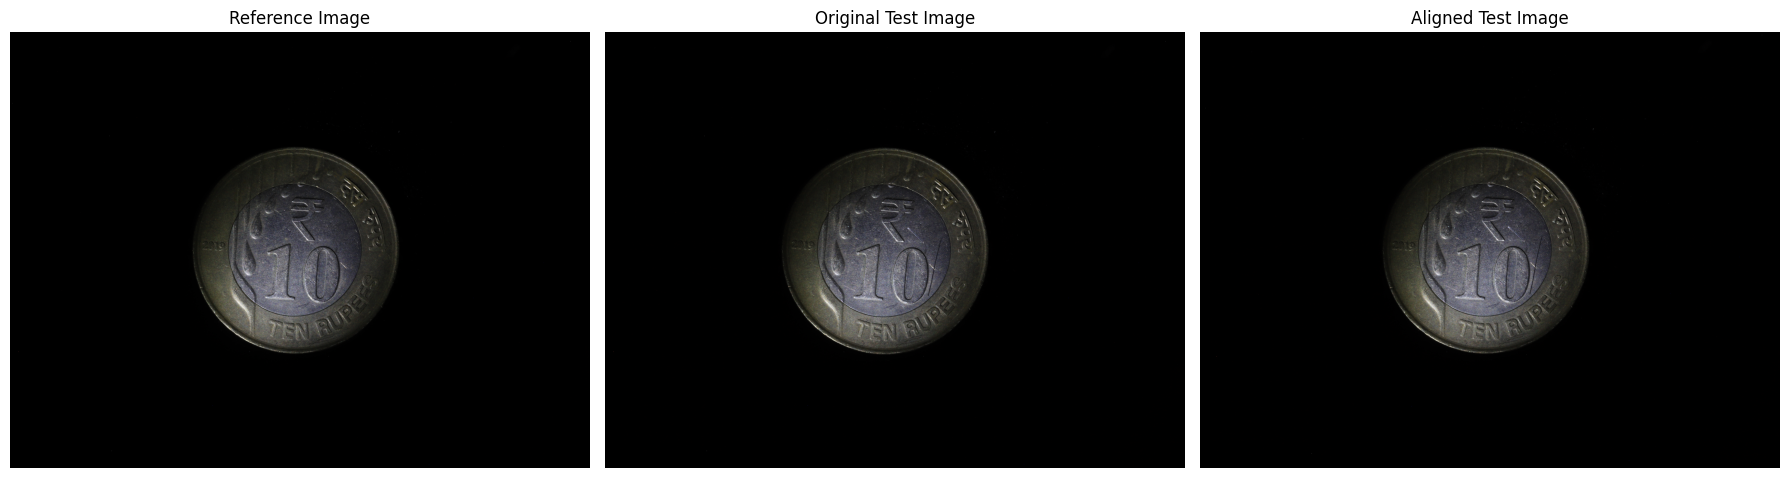

In [40]:
#slightly rotated images
ref_features, test_features, matches = featureMatching(slightly_rotated_1[0], slightly_rotated_1[1])
affine_matrix = affine_transformation(ref_features, test_features, matches)
aligned_image = affinewarping(slightly_rotated_1[0], slightly_rotated_1[1], affine_matrix) 

visualize_alignment(slightly_rotated_1[0], slightly_rotated_1[1], aligned_image)

Reference Keypoints: 9860
Test Image Keypoints: 9943
Good Matches Found: 20
Minimum Needed: 5 matches
Affine Transformation Matrix:
[[ 2.91454006e+01 -1.89552590e+01 -6.75264230e+04]
 [ 1.89552590e+01  2.91454006e+01 -9.07633038e+04]]
Scale X: 34.767171595386095, Scale Y: 34.767171595386095
Rotation Angle: 33.038719428748315 degrees
Translation X: -67526.42299976254, Translation Y: -90763.30379029899
[[ 2.91454006e+01 -1.89552590e+01 -6.75264230e+04]
 [ 1.89552590e+01  2.91454006e+01 -9.07633038e+04]]


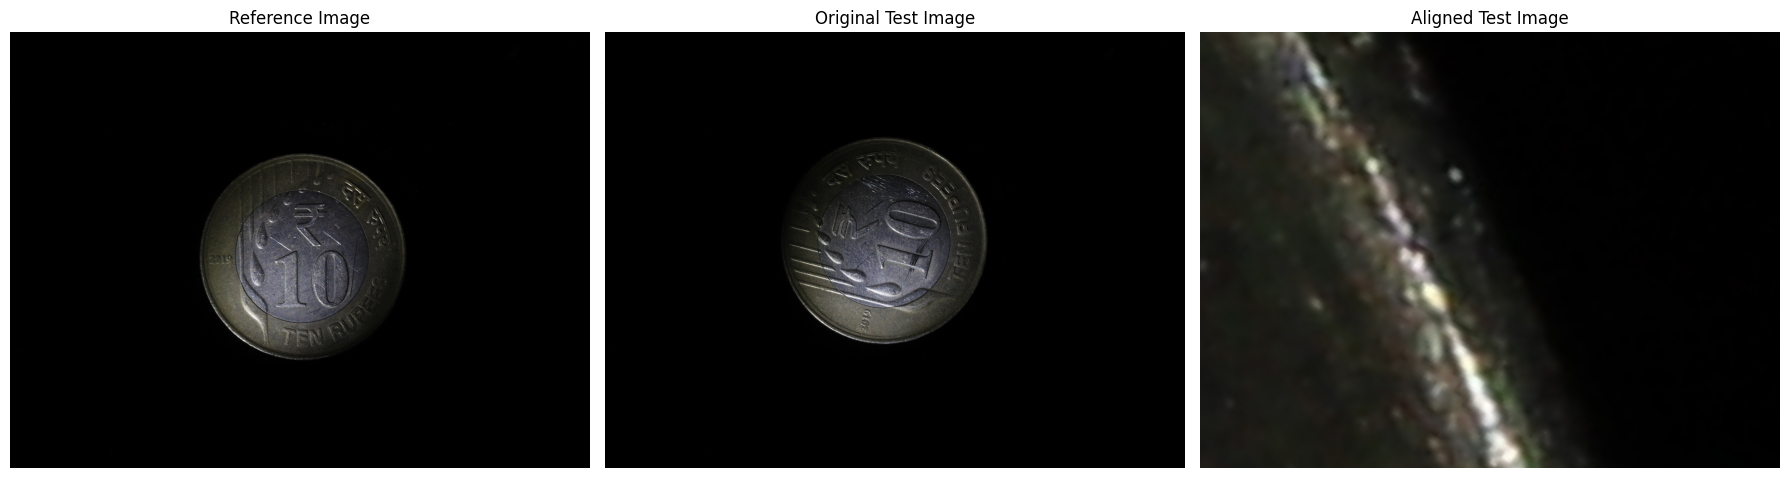

In [42]:
#exaggerated rotated images
ref_features, test_features, matches = featureMatching(exagerated_rotated_1[0], exagerated_rotated_1[1])
affine_matrix = affine_transformation(ref_features, test_features, matches)
aligned_image = affinewarping(exagerated_rotated_1[0], exagerated_rotated_1[1], affine_matrix)

cv.imwrite("aligned_exaggerated_rotated_1.png", aligned_image)

visualize_alignment(exagerated_rotated_1[0], exagerated_rotated_1[1], aligned_image)